## Correspondance avec les livrables (§9 du sujet)

| Livrable | Fichier / dossier |
|----------|-------------------|
| 1. Rapport scientifique | `rapport/rapport_scientifique.md` → PDF |
| 2. Code source commenté | `src/partie*.py` |
| 3. Notebook exécutable | ce fichier + `main.py` |
| 4. Annexe expérimentale | `annexe/` (généré par `py main.py`) |

Voir `LIVRABLES.md` à la racine du projet.

# Partie I – MLP et ingénierie PyTorch
**Projet Deep Learning — EMSI Casablanca 2025–2026**

**Dataset :** Breast Cancer Wisconsin (`sklearn.datasets`, intégré à scikit-learn)  
**Tâche :** classification binaire (tumeur maligne / bénigne)

Ce notebook couvre : théorie, préparation des données, deux implémentations MLP, initialisations, sauvegarde/chargement, GPU et métriques.

## 0. Dépendances

In [1]:
%pip install -q torch scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


## 1. Théorie – `nn.Module`, gradients et device

- **`nn.Module`** : abstraction PyTorch ; `forward()` définit la propagation avant.
- **Paramètres** : tenseurs apprenables (`weight`, `bias`) enregistrés automatiquement.
- **`state_dict()`** : dictionnaire nom → tenseur pour sauvegarder les poids.
- **Rétropropagation** : `loss.backward()` calcule les gradients ; l'optimiseur met à jour θ.
- **Device** : modèle et données doivent être sur le **même** device (CPU ou CUDA).

In [2]:
import copy
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

device = get_device()
print("Device :", device)
torch.manual_seed(42)
np.random.seed(42)

Device : cpu


## 2. Préparation des données

In [3]:
data = load_breast_cancer()
X = data.data.astype(np.float32)
y = data.target.astype(np.int64)
feature_names = data.feature_names
target_names = data.target_names

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

n_features = X_train.shape[1]
n_classes = len(np.unique(y))
print(f"Échantillons : train={len(X_train)}, val={len(X_val)}, test={len(X_test)}")
print(f"Features : {n_features}, classes : {list(target_names)}")

Échantillons : train=398, val=85, test=86
Features : 30, classes : [np.str_('malignant'), np.str_('benign')]


In [4]:
def make_loaders(X_tr, y_tr, X_va, y_va, batch_size=32):
    train_ds = TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr))
    val_ds = TensorDataset(torch.tensor(X_va), torch.tensor(y_va))
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True),
        DataLoader(val_ds, batch_size=batch_size),
    )

train_loader, val_loader = make_loaders(X_train, y_train, X_val, y_val)

## 3. MLP avec `nn.Sequential`

In [5]:
mlp_seq = nn.Sequential(
    nn.Linear(n_features, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, n_classes),
).to(device)

print("Architecture Sequential :")
print(mlp_seq)
for name, p in mlp_seq.named_parameters():
    print(f"  {name:30s} {tuple(p.shape)}")

Architecture Sequential :
Sequential(
  (0): Linear(in_features=30, out_features=128, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=128, out_features=64, bias=True)
  (4): ReLU()
  (5): Linear(in_features=64, out_features=2, bias=True)
)
  0.weight                       (128, 30)
  0.bias                         (128,)
  3.weight                       (64, 128)
  3.bias                         (64,)
  5.weight                       (2, 64)
  5.bias                         (2,)


## 4. MLP avec classe personnalisée

In [6]:
class MLPCustom(nn.Module):
    def __init__(self, in_dim, hidden=(128, 64), n_out=2, dropout=0.2):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden[0])
        self.fc2 = nn.Linear(hidden[0], hidden[1])
        self.out = nn.Linear(hidden[1], n_out)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        return self.out(x)

mlp_custom = MLPCustom(n_features, n_out=n_classes).to(device)
print(mlp_custom)
print("\nstate_dict (extrait) :", list(mlp_custom.state_dict().keys())[:4], "...")

MLPCustom(
  (fc1): Linear(in_features=30, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (out): Linear(in_features=64, out_features=2, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)

state_dict (extrait) : ['fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias'] ...


## 5. Initialisation – gaussienne, constante, Xavier

In [7]:
def init_normal(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0.0, std=0.01)
        nn.init.zeros_(m.bias)

def init_constant(m):
    if isinstance(m, nn.Linear):
        nn.init.constant_(m.weight, 1.0)
        nn.init.zeros_(m.bias)

def init_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

INIT_FNS = {
    "gaussienne": init_normal,
    "constante": init_constant,
    "xavier": init_xavier,
}

## 6. Boucle d'entraînement et évaluation

In [8]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        if is_train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += xb.size(0)
    return total_loss / total, correct / total


def predict_all(model, X):
    model.eval()
    with torch.no_grad():
        x = torch.tensor(X, dtype=torch.float32, device=device)
        return model(x).argmax(1).cpu().numpy()


def train_model(model, init_name="xavier", epochs=80, lr=1e-3):
    model = copy.deepcopy(model).to(device)
    model.apply(INIT_FNS[init_name])
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_state, best_acc = None, 0.0
    for ep in range(1, epochs + 1):
        tr_loss, _ = run_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_acc = run_epoch(model, val_loader, criterion)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        if va_acc > best_acc:
            best_acc = va_acc
            best_state = copy.deepcopy(model.state_dict())
    model.load_state_dict(best_state)
    return model, history, best_acc

Init gaussienne   → meilleure val accuracy : 0.9882


Init constante    → meilleure val accuracy : 0.9294


Init xavier       → meilleure val accuracy : 0.9882


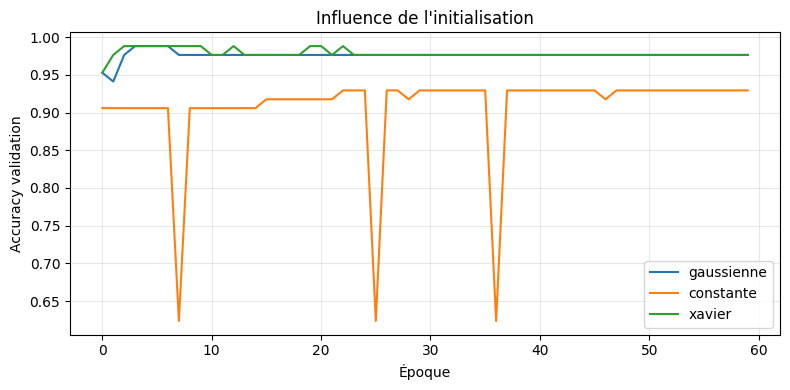

In [9]:
results_init = {}
histories = {}
for name in INIT_FNS:
    model, hist, val_acc = train_model(mlp_custom, init_name=name, epochs=60)
    results_init[name] = val_acc
    histories[name] = hist
    print(f"Init {name:12s} → meilleure val accuracy : {val_acc:.4f}")

plt.figure(figsize=(8, 4))
for name, h in histories.items():
    plt.plot(h["val_acc"], label=name)
plt.xlabel("Époque")
plt.ylabel("Accuracy validation")
plt.title("Influence de l'initialisation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Sauvegarde et rechargement du meilleur modèle

In [10]:
best_model, best_hist, _ = train_model(mlp_custom, init_name="xavier", epochs=80)
save_path = Path("checkpoints")
save_path.mkdir(exist_ok=True)
ckpt_file = save_path / "mlp_breast_cancer.pth"

torch.save(
    {
        "state_dict": best_model.state_dict(),
        "scaler_mean": scaler.mean_,
        "scaler_scale": scaler.scale_,
        "n_features": n_features,
        "n_classes": n_classes,
    },
    ckpt_file,
)
print("Modèle sauvegardé :", ckpt_file)

# Rechargement
loaded = MLPCustom(n_features, n_out=n_classes).to(device)
checkpoint = torch.load(ckpt_file, map_location=device, weights_only=False)
loaded.load_state_dict(checkpoint["state_dict"])
loaded.eval()

y_pred = predict_all(loaded, X_test)
print("Test accuracy (modèle rechargé) :", accuracy_score(y_test, y_pred))

Modèle sauvegardé : checkpoints\mlp_breast_cancer.pth
Test accuracy (modèle rechargé) : 0.9302325581395349


## 8. Comparaison Sequential vs Custom + métriques


=== Sequential ===
              precision    recall  f1-score   support

   malignant       0.93      0.88      0.90        32
      benign       0.93      0.96      0.95        54

    accuracy                           0.93        86
   macro avg       0.93      0.92      0.92        86
weighted avg       0.93      0.93      0.93        86



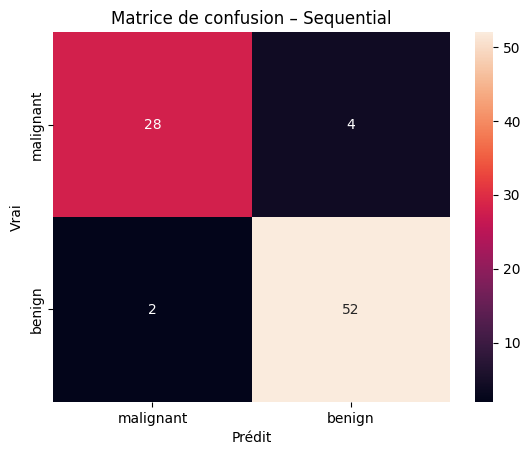

F1 : 0.9297415262906635 | Precision : 0.9303433001107421 | Recall : 0.9302325581395349

=== Custom ===
              precision    recall  f1-score   support

   malignant       0.96      0.84      0.90        32
      benign       0.91      0.98      0.95        54

    accuracy                           0.93        86
   macro avg       0.94      0.91      0.92        86
weighted avg       0.93      0.93      0.93        86



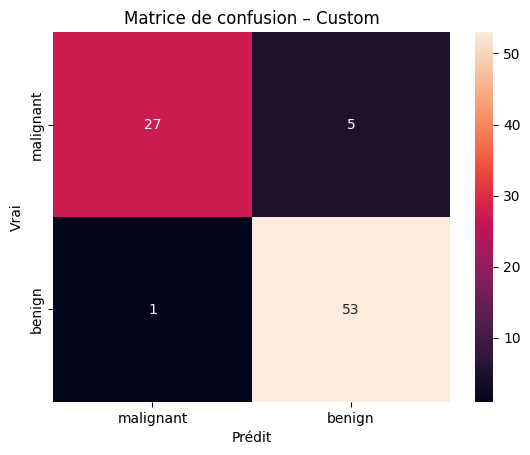

F1 : 0.9291528239202658 | Precision : 0.9325810516668576 | Recall : 0.9302325581395349


In [11]:
mlp_seq_trained, _, _ = train_model(mlp_seq, init_name="xavier", epochs=80)

for label, model in [("Sequential", mlp_seq_trained), ("Custom", best_model)]:
    y_pred = predict_all(model, X_test)
    print(f"\n=== {label} ===")
    print(classification_report(y_test, y_pred, target_names=target_names))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=target_names, yticklabels=target_names)
    plt.title(f"Matrice de confusion – {label}")
    plt.ylabel("Vrai")
    plt.xlabel("Prédit")
    plt.show()

    print(
        "F1 :", f1_score(y_test, y_pred, average="weighted"),
        "| Precision :", precision_score(y_test, y_pred, average="weighted"),
        "| Recall :", recall_score(y_test, y_pred, average="weighted"),
    )

## 9. Question de synthèse – Partie I

**Question :** Dans quelle mesure un MLP bien paramétré constitue-t-il une solution pertinente pour la classification tabulaire sur un dataset réel, et quelles sont ses principales limites ?

**Éléments à développer dans votre rapport** (à personnaliser avec vos chiffres) :

1. **Pertinence** : sur Breast Cancer, les features sont déjà structurées et de faible dimension (~30). Un MLP capture des interactions non linéaires entre biomarqueurs sans ingénierie de noyaux manuelle.
2. **Méthodologie** : normalisation indispensable ; split stratifié ; initialisation Xavier souvent plus stable que gaussienne/constante (symétrie des neurones).
3. **Résultats** : comparer accuracy/F1 entre initialisations et entre Sequential/Custom (performances proches si même capacité).
4. **Limites** : pas d'inductif bias pour la structure spatiale ou temporelle ; risque de surapprentissage si réseau trop large ; interprétabilité limitée vs modèles linéaires ou arbres ; besoin de beaucoup de données pour des tables haute dimension.

> Rédigez 1–2 pages en style académique en vous appuyant sur les courbes et tableaux ci-dessus.

## 10. Export vers l'annexe expérimentale

In [12]:
# Exécute depuis la racine du projet : py main.py --partie 1
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
from src import partie1_mlp
metrics = partie1_mlp.run(export=True, epochs=60)
print("→ Figures et tableaux dans annexe/partie1/")

  Dataset Breast Cancer : 569 echantillons, 30 features, device=cpu
  Split : train=398, val=85, test=86
  Comparaison des initialisations (gaussienne, constante, xavier)...
  [init-gaussienne] epoch 1/60 | val_acc=0.9529 | val_loss=0.6336


  [init-gaussienne] epoch 12/60 | val_acc=0.9765 | val_loss=0.0506


  [init-gaussienne] epoch 24/60 | val_acc=0.9765 | val_loss=0.0647


  [init-gaussienne] epoch 36/60 | val_acc=0.9765 | val_loss=0.0618


  [init-gaussienne] epoch 48/60 | val_acc=0.9765 | val_loss=0.0730


...

  [MLP-Sequential] epoch 24/60 | val_acc=0.9765 | val_loss=0.0398


  [MLP-Sequential] epoch 36/60 | val_acc=0.9765 | val_loss=0.0476


  [MLP-Sequential] epoch 48/60 | val_acc=0.9765 | val_loss=0.0548


  [MLP-Sequential] epoch 60/60 | val_acc=0.9765 | val_loss=0.0621
  [MLP-Sequential] meilleure val_acc=0.9882 (init=xavier)
  Test Sequential : accuracy=0.9302, F1=0.9285
  Test Custom : accuracy=0.9535, F1=0.9535


→ Figures et tableaux dans annexe/partie1/
